In [8]:
%pip install nltk

  Obtaining dependency information for nltk from https://files.pythonhosted.org/packages/1f/2b/bf677eb32ca6684b270c0d19ab133c2271e9f3375997e5a8dd2b08e3152d/nltk-3.10.2-py3-none-any.whl.metadata
  Obtaining dependency information for click from https://files.pythonhosted.org/packages/fb/e2/79c688af8b210d232694e31e59da9f6ec747bae31c3f5946e4e9b98860d5/click-8.4.2-py3-none-any.whl.metadata
  Obtaining dependency information for joblib from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for regex>=2021.8.3 from https://files.pythonhosted.org/packages/83/2b/cf1bc631db154eb95520d9d5dbc2371ff77a0f014bbf7d748fed8496aa63/regex-2026.7.19-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/41.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/41


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (9551, 21)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [5]:
print(df["Rating text"].value_counts())

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [6]:
review_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in ["review", "comment", "text"])
]

print("Possible review-text columns:")
print(review_columns)

Possible review-text columns:
['Rating text']


In [7]:
text_columns = df.select_dtypes(include="object").columns

print("Text/Object columns:")
print(text_columns.tolist())

Text/Object columns:
['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Rating color', 'Rating text']


# Dataset Limitation

The provided Cognifyz restaurant dataset does not contain customer-written review text.

The dataset contains a `Rating text` column representing rating categories such as Excellent, Very Good, Good, Average, and Poor. Since this column is a categorical description of the aggregate rating rather than free-form customer reviews, it cannot be appropriately used for keyword extraction or review-length analysis.

Therefore, positive/negative keyword extraction and review-length analysis cannot be performed reliably using the provided dataset without an additional review-text dataset.

In [8]:
rating_text_count = (
    df["Rating text"]
    .value_counts()
    .reset_index()
)

rating_text_count.columns = [
    "Rating Category",
    "Restaurant Count"
]

rating_text_count

,Rating Category,Restaurant Count
0,Average,3737
1,Not rated,2148
2,Good,2100
3,Very Good,1079
4,Excellent,301
5,Poor,186


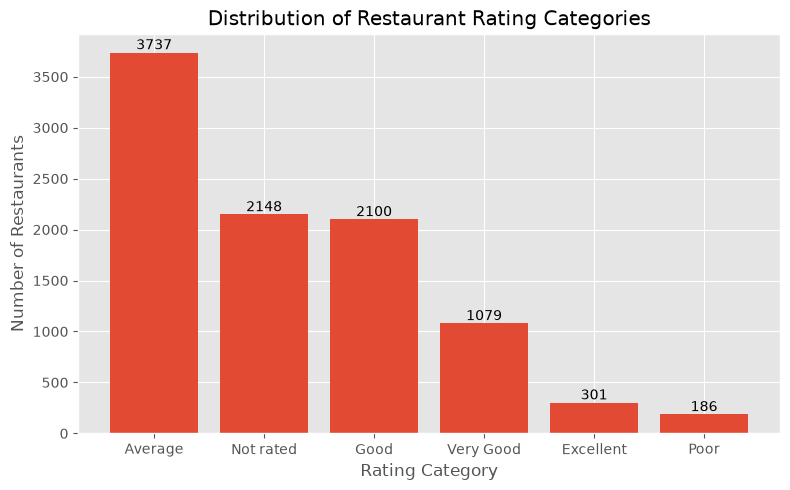

In [9]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_text_count["Rating Category"],
    rating_text_count["Restaurant Count"]
)

plt.title("Distribution of Restaurant Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [10]:
rating_summary = (
    df.groupby("Rating text")["Aggregate rating"]
      .agg(["count", "mean"])
      .reset_index()
)

rating_summary.columns = [
    "Rating Category",
    "Restaurant Count",
    "Average Aggregate Rating"
]

rating_summary

,Rating Category,Restaurant Count,Average Aggregate Rating
0,Average,3737,3.051619
1,Excellent,301,4.659801
2,Good,2100,3.683429
3,Not rated,2148,0.000000
4,Poor,186,2.297849
5,Very Good,1079,4.168119


# Observations

- The provided dataset does not contain free-form customer review text.
- The `Rating text` column contains predefined rating categories rather than written reviews.
- Therefore, positive and negative keyword extraction cannot be performed reliably from this dataset.
- Review length and its relationship with rating cannot be calculated without actual review text.
- As a supplementary analysis, the distribution of rating categories was examined.
- This limitation should be clearly documented rather than substituting rating categories for customer reviews.